# Final Exam (part 3) - Computational Physics I

### Deadline: Thursday 5 June 2025 (by 23h59)
### Credits: 10 points

### Please keep the structure provided below and submit an organised notebook with clear answers to each item.

## Name: Silva Alejandro

## 3. Wavelet analysis of seismic waves (10 points) 

Seismic signals recorded at a single station typically comprise a superposition of different wave types, primarily **P-waves** (due to compression), **S-waves** (due to shear), and **surface waves** (the ones that cause ground shaking). These waves propagate through the Earth at different velocities and possess distinct characteristic frequencies, making their isolation crucial for accurate seismic event analysis and hazard assessment.

#### Dataset:

Please download the following data file:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/1D-data/seismic_signals.csv

This dataset contains a mock time series of seismic waveform amplitude from two different seismic stations. The time is recorded in seconds ($\rm s$) and the wave amplitudes are in units of $\rm mm/s$.


#### Tasks:

The purpose of this problem is to develop a python pipeline (**using python functions**) that effectively isolates P-, S-, and surface waves from a given single-component seismic waveform using **wavelet transforms**, for which you need to carry out the following tasks:

### Requirements
The following libraries are required to run this notebook.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pywt
import scienceplots

In [2]:
# Set plots style
plt.style.use(['science', 'notebook', 'no-latex'])

### (a) Read the data file and carry out a time-frequency analysis of the seismic signal of the first station using appropriate wavelet transforms. Compute the scaleogram (i.e., the amplitude as a function of time and frequency) and the corresponding real frequencies.

In [3]:
def io_ssignals(filename):
    """
    This function reads a csv file containing the seismic signals recorded at two stations. It returns the columns of the file as arrays.
    ----------------------------
    Input: 
    filename -> str, path to the file.
    ----------------------------
    Outputs: 
    time -> array, time
    station1_a -> array, station 1 amplitude.
    station2_a -> array, station 2 amplitude.
    ----------------------------
    Author: AlejoS
    Date: 03/06/2025
    """
    # Read the csv file
    file_1 = pd.read_csv(filename) #the values are coma separated

    # Select file columns as arrays
    time = np.array(file_1["Time (s)"])
    station1_a = np.array(file_1["Station1_Amplitude (mm/s)"])
    station2_a = np.array(file_1["Station2_Amplitude (mm/s)"])

    return time, station1_a, station2_a

In [4]:
# Define the path to the file
filename = "./data/seismic_signals.csv" #modify to access your working directory
# Call our function
time, station1_a, station2_a = io_ssignals(filename)
# Safe check
#print(time.shape, station1_a.shape, station2_a.shape)

We'll first work just with the data recorded at Station 1.

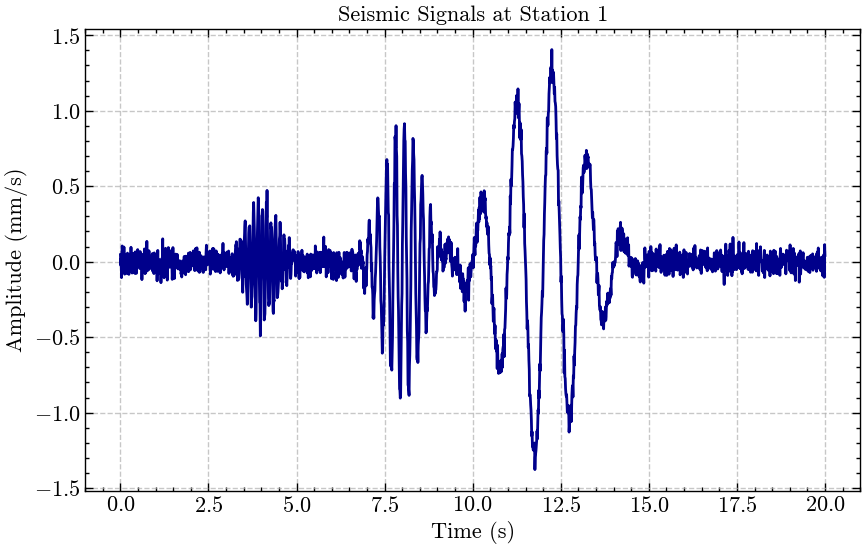

In [5]:
#First looking
plt.figure(figsize=(10, 6))
plt.plot(time, station1_a, color='darkblue')
plt.xlabel(r'Time (s)')
plt.ylabel(r'Amplitude (mm/s)')
plt.title(r'Seismic Signals at Station 1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
plt.close()

#### Wavelet analysis
https://paos.colorado.edu/research/wavelets/bams_79_01_0061.pdf

We'll use the Continuous Wavelet Transform (CWT) since "it involves a transform from a one-dimensional time series (or frequency spectrum) to a diffuse two-dimensional time–frequency image", as stated in the mentioned paper. It does not make sense to use the DWT since we'll just obtain the approximation coefficients (cA) and the detail coefficients (cD), with no frequency nor time information.

In [6]:
# Wavelet analysis. According to the documentation for pywt.cwt,\
# we need to define the wavelet and its scales and the sampling period.
# https://pywavelets.readthedocs.io/en/latest/ref/cwt.html#the-cwt-function

# Choose a wavelet
#print(pywt.wavelist(kind = "continuous"))
wavelet1 = 'shan1-1'  # Shannon wavelet, it resembles the structures seen on the plot above.

# Define the sampling period
sampling_period = np.diff(time).mean()

# Define the wavelets scales to use.
# "The scales determine the frequency resolution of the scaleogram".
scales = np.arange(1, 200, 0.1)

# Carry out the CWT
coeffs1, freqs1 = pywt.cwt(station1_a, scales, wavelet1, sampling_period)
#print(coeffs1[10, 10]) # it has complex values
#print(coeffs1.shape, freqs1.shape)

### (b) Make two plots of the resulting 2D scalogram: one projection plot in 2D and another one as a 3D surface plot, ensuring both visualisations display the correct frequencies versus time. These plots are essential for visualising the frequency content of the different wave arrivals over time, which will inform the subsequent wave isolation process.

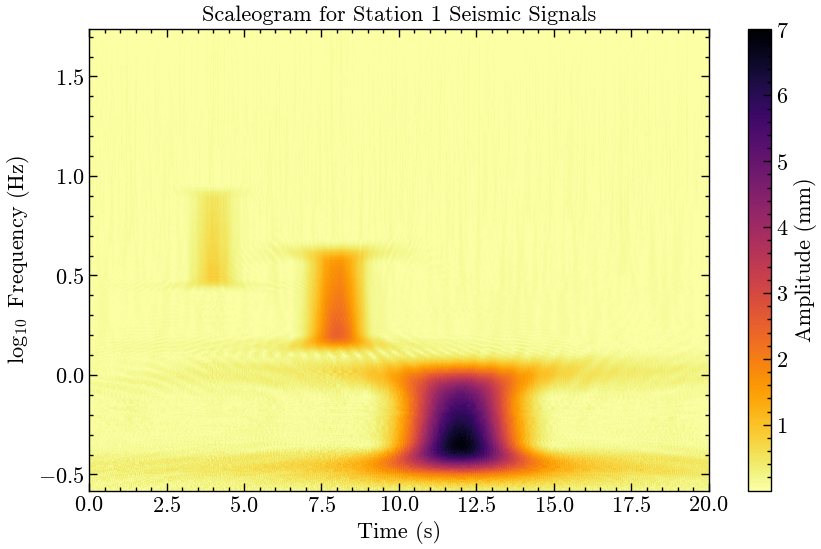

In [7]:
# Plotting the projection in the time-frequency domain.
plt.figure(figsize=(10, 6))
z = plt.pcolormesh(time, np.log10(freqs1), np.abs(coeffs1), shading='auto', cmap='inferno_r')
#Labeling
plt.title(r'Scaleogram for Station 1 Seismic Signals')
plt.xlabel(r'Time (s)')
plt.ylabel(r'$\log_{10}$ Frequency (Hz)')
plt.colorbar(z, label = r'Amplitude (mm)')

plt.show()
plt.close()

We see 3 characteristic shapes, matching the objects seen on the first inspection we did.

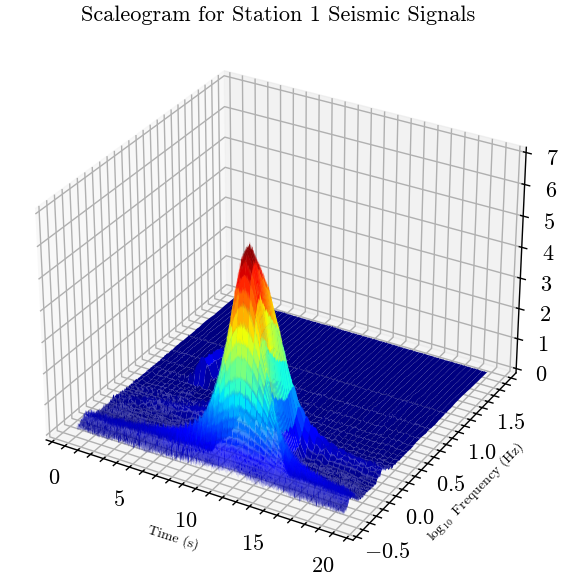

In [8]:
# Plotting the 3D surface, over the time-frequency domain.
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d') 
# Create a meshgrid
X, Y = np.meshgrid(time, np.log10(freqs1))
#Plotting the surface
ax.plot_surface(X, Y, np.abs(coeffs1), cmap='jet')
ax.set_title(r'Scaleogram for Station 1 Seismic Signals')
ax.set_xlabel(r'Time (s)', fontsize = 10)
ax.set_ylabel(r'$\log_{10}$ Frequency (Hz)', fontsize = 10)


plt.tight_layout()
plt.show()
plt.close()    

### (c) Based on the insights gained from your scalogram plots, provide the approximate frequency ranges associated with the P-waves, S-waves, and surface waves observed in the seismic signal. Justify your identification with reference to the visual characteristics of the scaleogram.

P-waves are the first to arrive at the station, followed by S-waves, and finally surface waves, which have the lowest frequency of them all.

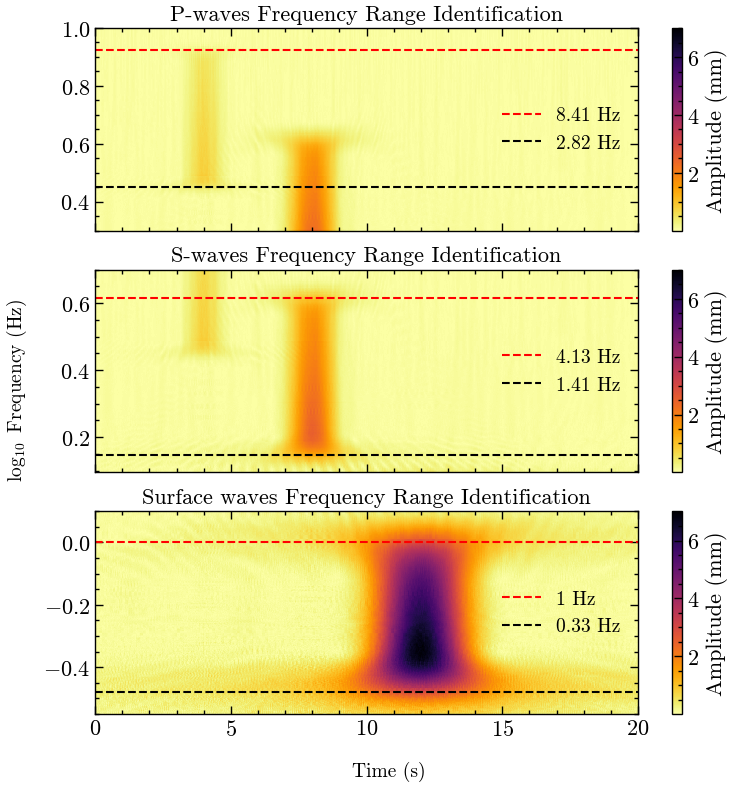

In [9]:
# Zoom in the time-frequency domain.
# Multi-panel figure
fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
fig.supylabel(r'$\log_{10}$ Frequency (Hz)', fontsize=14)
fig.supxlabel(r'Time (s)', fontsize=14)

# P-waves
z = axs[0].pcolormesh(time, np.log10(freqs1), np.abs(coeffs1), shading='auto', cmap='inferno_r')
axs[0].set_title(r'P-waves Frequency Range Identification')
axs[0].set_ylim(0.3, 1)
axs[0].axhline(0.925, color='red', linestyle='--', linewidth=1.5, label='8.41 Hz') #10**0.925 = 8.41
axs[0].axhline(0.45, color='black', linestyle='--', linewidth=1.5, label='2.82 Hz') #10**0.45 = 2.82
axs[0].legend(fancybox=True, loc='center right', fontsize=14)
fig.colorbar(z, ax=axs[0], label=r'Amplitude (mm)')

# S-waves
z = axs[1].pcolormesh(time, np.log10(freqs1), np.abs(coeffs1), shading='auto', cmap='inferno_r')
axs[1].set_title(r'S-waves Frequency Range Identification')
axs[1].set_ylim(0.095, 0.7)
axs[1].axhline(0.616, color='red', linestyle='--', linewidth=1.5, label='4.13 Hz') #10**0.616 = 4.13
axs[1].axhline(0.148, color='black', linestyle='--', linewidth=1.5, label='1.41 Hz') #10**0.148 = 1.41
axs[1].legend(fancybox=True, loc='center right', fontsize=14)
fig.colorbar(z, ax=axs[1], label=r'Amplitude (mm)')

# Surface-waves
z = axs[2].pcolormesh(time, np.log10(freqs1), np.abs(coeffs1), shading='auto', cmap='inferno_r')
axs[2].set_title(r'Surface waves Frequency Range Identification')
axs[2].set_ylim(-0.55, 0.1)
axs[2].axhline(0, color='red', linestyle='--', linewidth=1.5, label='1 Hz') #10**0 = 1
axs[2].axhline(-0.48, color='black', linestyle='--', linewidth=1.5, label='0.33 Hz') #10**-0.48 = 0.33
axs[2].legend(fancybox=True, loc='center right', fontsize=14)
fig.colorbar(z, ax=axs[2], label=r'Amplitude (mm)')

# Adjust layout
plt.tight_layout()
plt.show()
plt.close()

### (d) Before performing a Discrete Wavelet Transform (DWT), determine the sampling frequency of the seismic signal. Then, for a chosen DWT decomposition level, calculate and state the theoretical frequency ranges corresponding to the approximation and all relevant detail coefficients.

We reference the following paper, specifically the sections $\textit{Level Selection}$ and $\textit{Mother Wavelet Selection}$.

https://www.nature.com/articles/s41598-024-82025-2#Sec7 (it's open access)

In [10]:
#f = 1/T
#sampling_period = np.diff(time).mean()
sampling_frequency = 1/sampling_period
print(f"The sampling frequency of the seismic signal is {sampling_frequency} Hz.")

The sampling frequency of the seismic signal is 99.95 Hz.


Now, from our frequency ranges results we saw that for the frequency range of $0.33-1 Hz$ the amplitude (energy) was the biggest. So, we select the decomposition level that best captures the dominant features of this low-frequency band. After some trials, we found that it's $\textbf{cD5}$, or maybe a combination or cD4 and cD5 could be used.

In [11]:
# Choosing a mother wavelet.
#print(pywt.wavelist(kind = "discrete"))
# We're looking for the discrete wavelet that matches the maximum level of decomposition found.
max_level = pywt.dwt_max_level(station1_a.size, "coif10")
print(f"The maximum level of decomposition is {max_level}.")

The maximum level of decomposition is 5.


### (e) Apply a suitable DWT to the seismic signal to decompose it into approximation and detail coefficients at multiple levels. The choice of wavelet family and decomposition level should be justified based on the characteristic frequencies of the seismic waves identified in the previous steps.

In [12]:
# Define the wavelet
wavelet2 = "coif10"
# Multi-level wavelet analysis
coeffs2 = pywt.wavedec(station1_a, wavelet2, level = 5, mode = "periodic")

# Safe check
#print(len(coeffs2))

# Unpacking the coefficients
cA5, cD5, cD4, cD3, cD2, cD1 = coeffs2 

### (f) Based on the understanding that different seismic wave types occupy distinct frequency bands (e.g., P-waves tend to have higher frequencies, S-waves mid-range, and surface waves lower frequencies), strategically manipulate the wavelet coefficients to reconstruct the isolated wave types. Specifically:

- **P-waves:** Reconstruct P-waves primarily from higher-frequency detail coefficients.
- **S-waves:** Reconstruct S-waves primarily from mid-frequency detail coefficients.
- **Surface Waves:** Reconstruct surface waves primarily from the lowest-frequency approximation coefficients.

In [13]:
# Making copies of the coefficients
coeffs2_copy1 = coeffs2.copy()
coeffs2_copy2 = coeffs2.copy()
coeffs2_copy3 = coeffs2.copy()

#### Isolating surface waves

In [14]:
# Just using cA. Filtering.
coeffs2_copy1[1] = np.zeros_like(coeffs2_copy1[1])
coeffs2_copy1[2] = np.zeros_like(coeffs2_copy1[2])
coeffs2_copy1[3] = np.zeros_like(coeffs2_copy1[3])
coeffs2_copy1[-2] = np.zeros_like(coeffs2_copy1[-2])
coeffs2_copy1[-1] = np.zeros_like(coeffs2_copy1[-1])
#Safe check
#print(coeffs2_copy1)
#print(cA5)

#### Isolating S-waves

In [15]:
# Just using cD4. Filtering.
coeffs2_copy2[0] = np.zeros_like(coeffs2_copy2[0])
coeffs2_copy2[1] = np.zeros_like(coeffs2_copy2[1])
coeffs2_copy2[3] = np.zeros_like(coeffs2_copy2[3])
coeffs2_copy2[-2] = np.zeros_like(coeffs2_copy2[-2])
coeffs2_copy2[-1] = np.zeros_like(coeffs2_copy2[-1])
#Safe check
#print(coeffs2_copy2)
#print(cA5)

#### Isolating P-waves

In [16]:
# Just using cD3. Filtering.
coeffs2_copy3[0] = np.zeros_like(coeffs2_copy3[0])
coeffs2_copy3[1] = np.zeros_like(coeffs2_copy3[1])
coeffs2_copy3[2] = np.zeros_like(coeffs2_copy3[2])
#coeffs2_copy3[3] = np.zeros_like(coeffs2_copy3[3])
coeffs2_copy3[-2] = np.zeros_like(coeffs2_copy3[-2])
coeffs2_copy3[-1] = np.zeros_like(coeffs2_copy3[-1])

#Safe check
#print(coeffs2_copy2)
#print(cA5)

### (g) Reconstruct the isolated P-, S-, and surface wave signals using the modified wavelet coefficients.

#### Reconstructing Surface waves

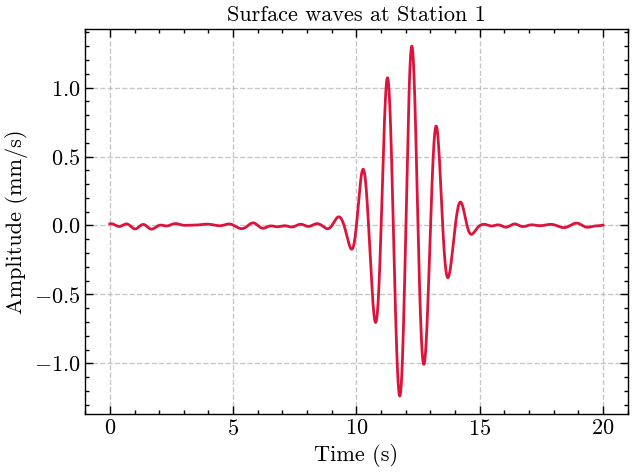

In [17]:
# Reconstructing the signal
surfacew_station1 = pywt.waverec(coeffs2_copy1, wavelet2, mode = 'periodic')

# Plotting
plt.figure(figsize=(7, 5))
plt.plot(time, surfacew_station1, color='crimson')
plt.xlabel(r'Time (s)')
plt.ylabel(r'Amplitude (mm/s)')
plt.title(r'Surface waves at Station 1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
plt.close()

#### Reconstructing S-waves

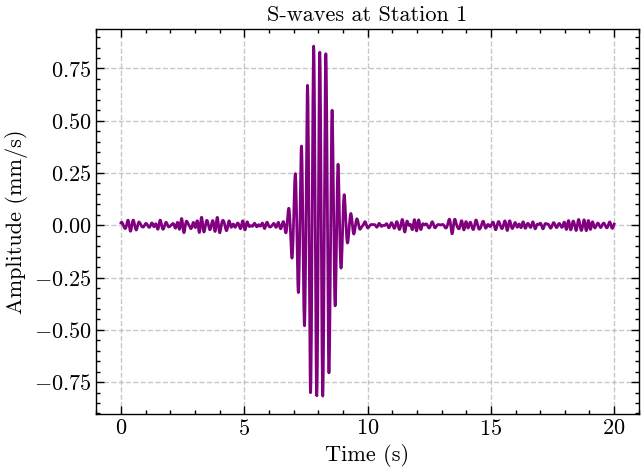

In [18]:
# Reconstructing the signal
sw_station1 = pywt.waverec(coeffs2_copy2, wavelet2, mode = 'periodic')

# Plotting
plt.figure(figsize=(7, 5))
plt.plot(time, sw_station1, color='purple')
plt.xlabel(r'Time (s)')
plt.ylabel(r'Amplitude (mm/s)')
plt.title(r'S-waves at Station 1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
plt.close()

#### Reconstructing P-waves

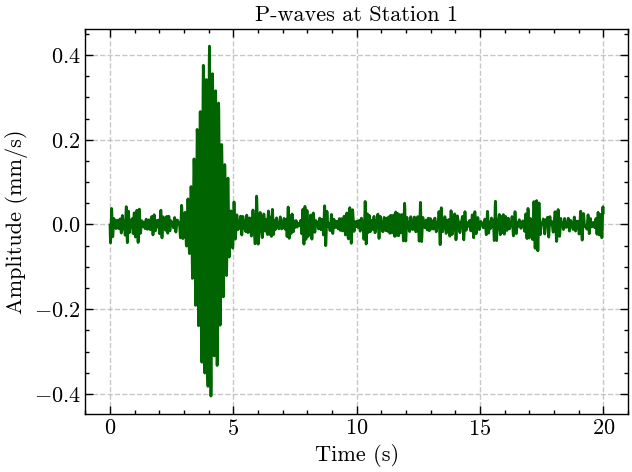

In [19]:
# Reconstructing the signal
pw_station1 = pywt.waverec(coeffs2_copy3, wavelet2, mode = 'periodic')

# Plotting
plt.figure(figsize=(7, 5))
plt.plot(time, pw_station1, color='darkgreen')
plt.xlabel(r'Time (s)')
plt.ylabel(r'Amplitude (mm/s)')
plt.title(r'P-waves at Station 1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
plt.close()

#### Comparison of frequency ranges using FFT

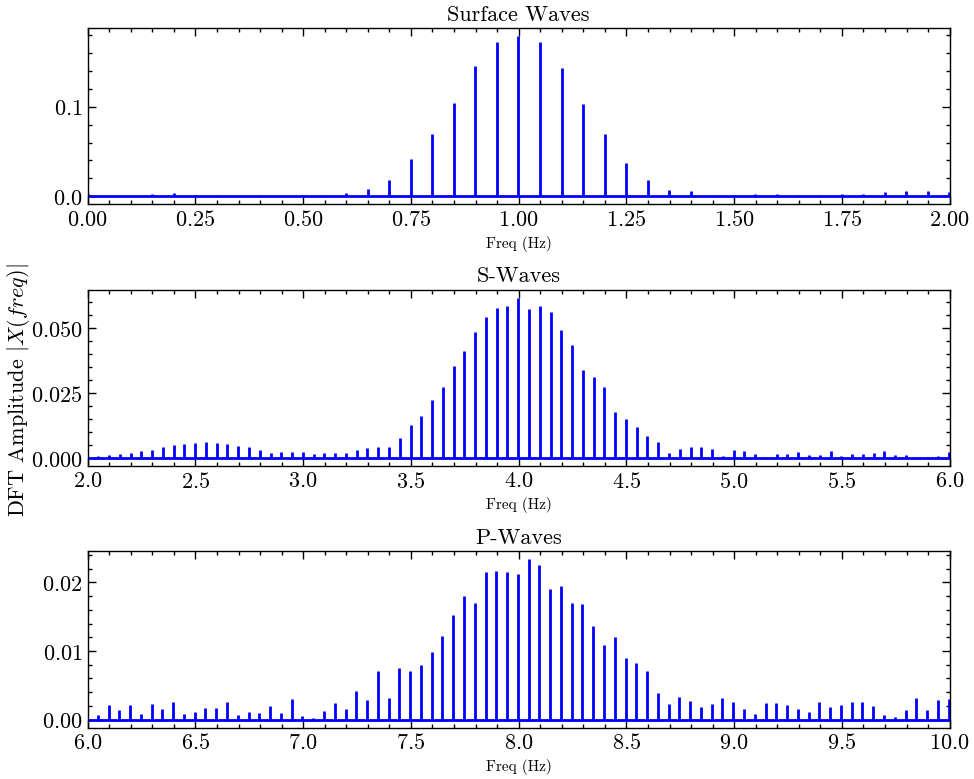

In [20]:
# FFT
# Surface waves
fft_surfacew = np.fft.fft(surfacew_station1)
signal_size_sw = surfacew_station1.size
freqs_surfacew = np.fft.fftfreq(signal_size_sw, sampling_period)

# S-waves
fft_sw = np.fft.fft(sw_station1)
signal_size_s = sw_station1.size
freqs_s = np.fft.fftfreq(signal_size_s, sampling_period)

# P-waves
fft_pw = np.fft.fft(pw_station1)
signal_size_p = pw_station1.size
freqs_p = np.fft.fftfreq(signal_size_p, sampling_period)

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
fig.supylabel(r'DFT Amplitude $|X(freq)|$', fontsize = 16)

# Surface waves
axs[0].stem(freqs_surfacew[:signal_size_sw//2], 
            (abs(fft_surfacew)[:signal_size_sw//2])/(signal_size_sw//2), 
            linefmt="b", markerfmt=" ", basefmt="-b")
axs[0].set_xlim(0, 2)
axs[0].set_xlabel("Freq (Hz)", fontsize = 11)
axs[0].set_title("Surface Waves")

# S-waves
axs[1].stem(freqs_s[:signal_size_s//2], 
            (abs(fft_sw)[:signal_size_s//2])/(signal_size_s//2), 
            linefmt="b", markerfmt=" ", basefmt="-b")
axs[1].set_xlim(2, 6)
axs[1].set_xlabel("Freq (Hz)", fontsize = 11)
axs[1].set_title("S-Waves")

# P-waves
axs[2].stem(freqs_p[:signal_size_p//2], 
            (abs(fft_pw)[:signal_size_p//2])/(signal_size_p//2), 
            linefmt="b", markerfmt=" ", basefmt="-b")
axs[2].set_xlim(6, 10)
axs[2].set_xlabel("Freq (Hz)", fontsize = 11)
axs[2].set_title("P-Waves")

plt.tight_layout()
plt.show()

They do match the frequency ranges found before on the scaleogram.

### (h) Make a multi-panel figure of the first seismic waveform alongside the separated P-, S-, and surface wave components to demonstrate the effectiveness of the pipeline.

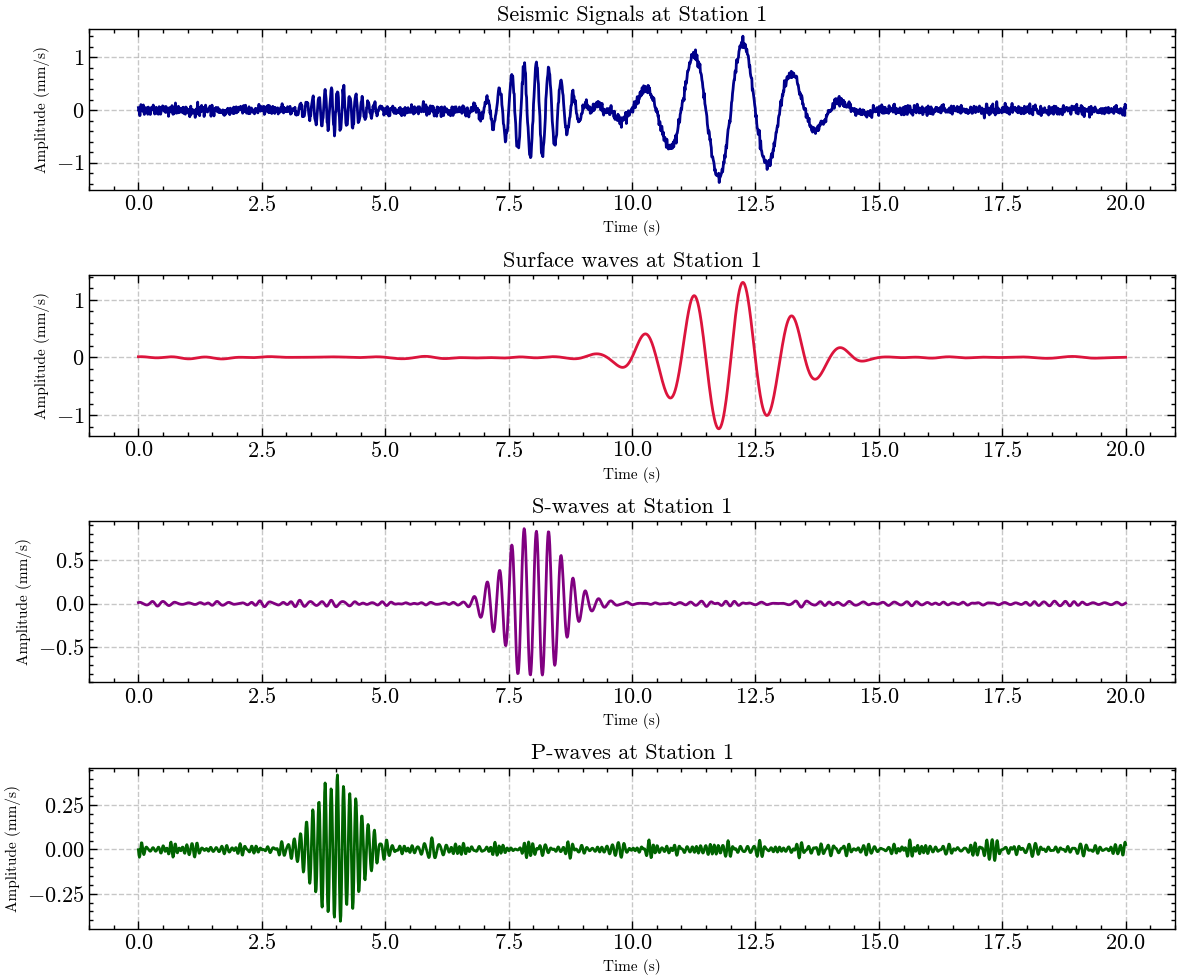

In [21]:
# Multi-panel figure comparison
fig, axs = plt.subplots(4, 1, figsize=(12, 10))
axs = axs.flatten()

# Main Seismic Signal
axs[0].plot(time, station1_a, color='darkblue')
axs[0].set_title(r'Seismic Signals at Station 1')
axs[0].set_xlabel(r'Time (s)', fontsize = 11)
axs[0].set_ylabel(r'Amplitude (mm/s)', fontsize = 11)
axs[0].grid(True, linestyle='--', alpha=0.7)

# Surface Waves
axs[1].plot(time, surfacew_station1, color='crimson')
axs[1].set_title(r'Surface waves at Station 1')
axs[1].set_xlabel(r'Time (s)', fontsize = 11)
axs[1].set_ylabel(r'Amplitude (mm/s)', fontsize = 11)
axs[1].grid(True, linestyle='--', alpha=0.7)

# S-Waves
axs[2].plot(time, sw_station1, color='purple')
axs[2].set_title(r'S-waves at Station 1')
axs[2].set_xlabel(r'Time (s)', fontsize = 11)
axs[2].set_ylabel(r'Amplitude (mm/s)', fontsize = 11)
axs[2].grid(True, linestyle='--', alpha=0.7)

# P-Waves
axs[3].plot(time, pw_station1, color='darkgreen')
axs[3].set_title(r'P-waves at Station 1')
axs[3].set_xlabel(r'Time (s)', fontsize = 11)
axs[3].set_ylabel(r'Amplitude (mm/s)', fontsize = 11)
axs[3].grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()
plt.close()

### (i) Validate the code by applying the pipeline to the data of the second station. Make a multi-panel figure of the second seismic waveform alongside the separated P-, S-, and surface wave components to demonstrate the effectiveness of the pipeline.

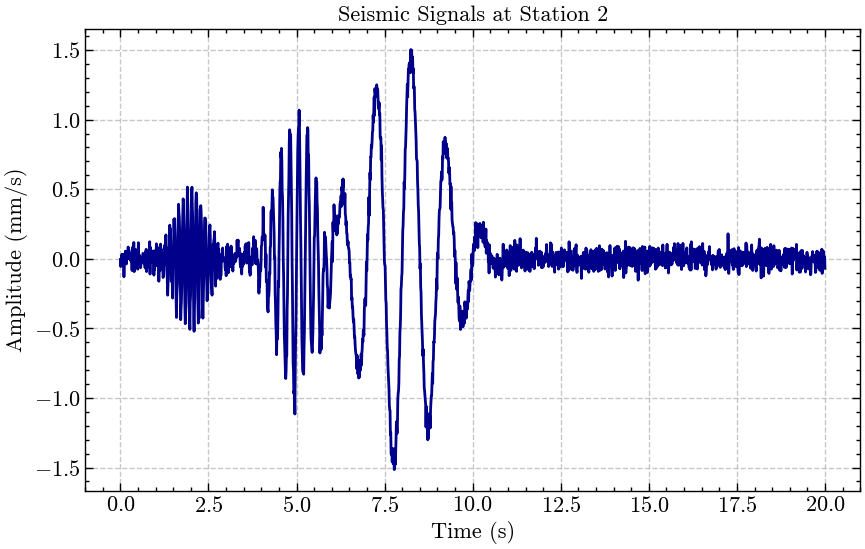

In [22]:
#First looking
plt.figure(figsize=(10, 6))
plt.plot(time, station2_a, color='darkblue')
plt.xlabel(r'Time (s)')
plt.ylabel(r'Amplitude (mm/s)')
plt.title(r'Seismic Signals at Station 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
plt.close()

In [23]:
# Define the wavelet
wavelet2 = "coif10"
# Multi-level wavelet analysis
coeffs3 = pywt.wavedec(station2_a, wavelet2, level = 5, mode = "periodic")

# Safe check
#print(len(coeffs2))

# Unpacking the coefficients
cA5, cD5, cD4, cD3, cD2, cD1 = coeffs3 

In [24]:
# Making copies of the coefficients
coeffs3_copy1 = coeffs3.copy()
coeffs3_copy2 = coeffs3.copy()
coeffs3_copy3 = coeffs3.copy()

#### Isolating and reconstructing seismic waves

In [25]:
# Surface waves
coeffs3_copy1[1] = np.zeros_like(coeffs3_copy1[1])
coeffs3_copy1[2] = np.zeros_like(coeffs3_copy1[2])
coeffs3_copy1[3] = np.zeros_like(coeffs3_copy1[3])
coeffs3_copy1[-2] = np.zeros_like(coeffs3_copy1[-2])
coeffs3_copy1[-1] = np.zeros_like(coeffs3_copy1[-1])

# Reconstructing the signal
surfacew_station2 = pywt.waverec(coeffs3_copy1, wavelet2, mode = 'periodic')


# S-waves
coeffs3_copy2[0] = np.zeros_like(coeffs3_copy2[0])
coeffs3_copy2[1] = np.zeros_like(coeffs3_copy2[1])
coeffs3_copy2[3] = np.zeros_like(coeffs3_copy2[3])
coeffs3_copy2[-2] = np.zeros_like(coeffs3_copy2[-2])
coeffs3_copy2[-1] = np.zeros_like(coeffs3_copy2[-1])

# Reconstructing the signal
sw_station2 = pywt.waverec(coeffs3_copy2, wavelet2, mode = 'periodic')

#P-waves
coeffs3_copy3[0] = np.zeros_like(coeffs3_copy3[0])
coeffs3_copy3[1] = np.zeros_like(coeffs3_copy3[1])
coeffs3_copy3[2] = np.zeros_like(coeffs3_copy3[2])
#coeffs3_copy3[3] = np.zeros_like(coeffs3_copy3[3])
coeffs3_copy3[-2] = np.zeros_like(coeffs3_copy3[-2])
coeffs3_copy3[-1] = np.zeros_like(coeffs3_copy3[-1])

# Reconstructing the signal
pw_station2 = pywt.waverec(coeffs3_copy3, wavelet2, mode = 'periodic')

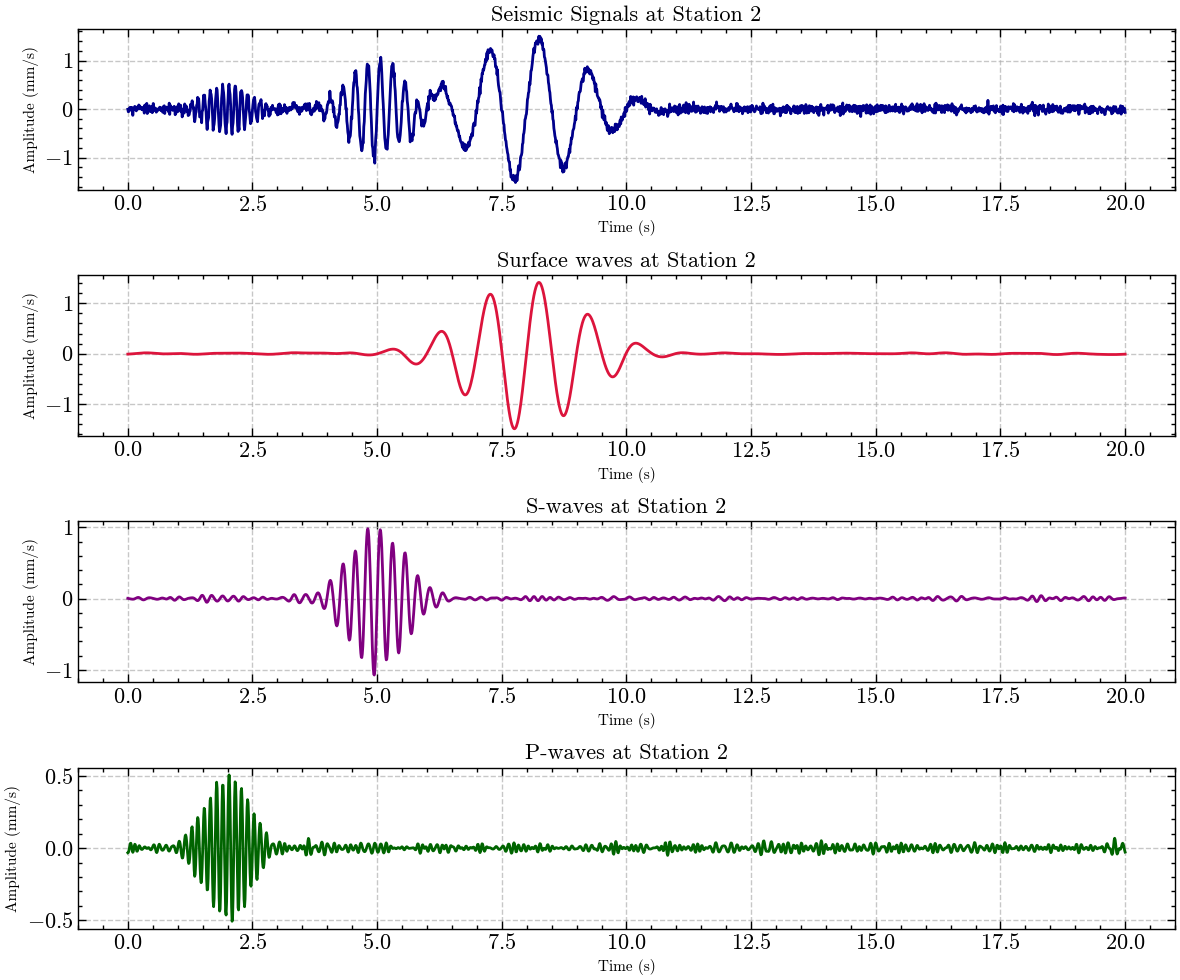

In [26]:
# Multi-panel figure comparison
fig, axs = plt.subplots(4, 1, figsize=(12, 10))
axs = axs.flatten()

# Main Seismic Signal
axs[0].plot(time, station2_a, color='darkblue')
axs[0].set_title(r'Seismic Signals at Station 2')
axs[0].set_xlabel(r'Time (s)', fontsize = 11)
axs[0].set_ylabel(r'Amplitude (mm/s)', fontsize = 11)
axs[0].grid(True, linestyle='--', alpha=0.7)

# Surface Waves
axs[1].plot(time, surfacew_station2, color='crimson')
axs[1].set_title(r'Surface waves at Station 2')
axs[1].set_xlabel(r'Time (s)', fontsize = 11)
axs[1].set_ylabel(r'Amplitude (mm/s)', fontsize = 11)
axs[1].grid(True, linestyle='--', alpha=0.7)

# S-Waves
axs[2].plot(time, sw_station2, color='purple')
axs[2].set_title(r'S-waves at Station 2')
axs[2].set_xlabel(r'Time (s)', fontsize = 11)
axs[2].set_ylabel(r'Amplitude (mm/s)', fontsize = 11)
axs[2].grid(True, linestyle='--', alpha=0.7)

# P-Waves
axs[3].plot(time, pw_station2, color='darkgreen')
axs[3].set_title(r'P-waves at Station 2')
axs[3].set_xlabel(r'Time (s)', fontsize = 11)
axs[3].set_ylabel(r'Amplitude (mm/s)', fontsize = 11)
axs[3].grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()
plt.close()

### (j) Does your code successfully isolate the different wave components of the seismic signals?

According to the multi-panel figures above regarding both stations, it does isolate the wave components of the seismic signals successfully. However, there is still some noise which is expected because of frequency overlap.